In [1]:
# Cell 1: Verify Required Packages
# All packages should be pre-installed in the 'densecap-gpu' venv.
# If any import fails, run: pip install <package> in your venv terminal.

import importlib

required_packages = {
    'torch': 'torch',
    'torchvision': 'torchvision',
    'torchaudio': 'torchaudio',
    'transformers': 'transformers',
    'detectron2': 'detectron2',
    'timm': 'timm',
    'cv2': 'opencv-python',
    'pycocotools': 'pycocotools',
    'lvis': 'lvis',
    'einops': 'einops',
    'accelerate': 'accelerate',
    'bitsandbytes': 'bitsandbytes',
}

all_ok = True
for module_name, pip_name in required_packages.items():
    try:
        importlib.import_module(module_name)
        print(f'✓ {module_name}')
    except ImportError:
        print(f'✗ {module_name} — run: pip install {pip_name}')
        all_ok = False

if all_ok:
    print('\n✓ All packages verified successfully!')
else:
    print('\n✗ Some packages are missing. Install them and re-run this cell.')


✓ torch
✓ torchvision
✓ torchaudio


y:\Research_Windows\.venv\Lib\site-packages\transformers\utils\generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


✓ transformers
✓ detectron2
✓ timm
✓ cv2
✓ pycocotools
✓ lvis
✓ einops
✓ accelerate


W0225 22:15:26.160000 34468 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


✓ bitsandbytes

✓ All packages verified successfully!


In [2]:
# Cell 2: Import all necessary libraries

# ============================================================
# CRITICAL: Set ALL HuggingFace cache env vars BEFORE imports
# ============================================================
import os

# Base cache directory on Y: drive
cache_dir = r'Y:\Research_Windows\huggingface_cache'
os.makedirs(cache_dir, exist_ok=True)

# Sub-directories matching HuggingFace's expected structure
hub_cache = os.path.join(cache_dir, 'hub')
modules_cache = os.path.join(cache_dir, 'modules')
offload_dir = os.path.join(cache_dir, 'offload')
os.makedirs(hub_cache, exist_ok=True)
os.makedirs(modules_cache, exist_ok=True)
os.makedirs(offload_dir, exist_ok=True)

# Set ALL cache environment variables
os.environ['HF_HOME'] = cache_dir                    # Master switch
os.environ['HF_HUB_CACHE'] = hub_cache               # Where model repos are cloned (CURRENT var name)
os.environ['HUGGINGFACE_HUB_CACHE'] = hub_cache       # Old name, kept for compat
os.environ['TRANSFORMERS_CACHE'] = hub_cache           # Transformers-specific
os.environ['HF_MODULES_CACHE'] = modules_cache        # Where trust_remote_code downloads go
os.environ['HF_DATASETS_CACHE'] = os.path.join(cache_dir, 'datasets')
os.environ['HF_METRICS_CACHE'] = cache_dir
os.environ['ACCELERATE_CACHE'] = cache_dir
os.environ['TORCH_HOME'] = cache_dir

# Now import other libraries
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from dataclasses import dataclass
import logging
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# Transformers & HuggingFace
from transformers import (
    AutoTokenizer, 
    AutoModelForCausalLM,
    BitsAndBytesConfig
)

# Force huggingface_hub to use our paths (belt + suspenders)
try:
    import huggingface_hub.constants as hf_constants
    hf_constants.HF_HOME = cache_dir
    hf_constants.HF_HUB_CACHE = hub_cache
    hf_constants.HUGGINGFACE_HUB_CACHE = hub_cache
    hf_constants.HF_MODULES_CACHE = modules_cache
    if hasattr(hf_constants, 'default_home'):
        hf_constants.default_home = cache_dir
    if hasattr(hf_constants, 'default_cache_path'):
        hf_constants.default_cache_path = hub_cache
    print(f'\u2713 Patched huggingface_hub.constants to use Y: drive')
except Exception as e:
    print(f'Warning: Could not patch huggingface_hub constants: {e}')

# Detectron2
import detectron2
from detectron2.config import get_cfg
from detectron2.engine import DefaultPredictor
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog
from detectron2.structures import Boxes, Instances

# Set up logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")
print(f"CUDA Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
print(f"HF Cache: {cache_dir}")
print(f"HF Hub Cache: {hub_cache}")
print(f"HF Modules Cache: {modules_cache}")


✓ Patched huggingface_hub.constants to use Y: drive
Using device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti
CUDA Memory: 17.10 GB
HF Cache: Y:\Research_Windows\huggingface_cache
HF Hub Cache: Y:\Research_Windows\huggingface_cache\hub
HF Modules Cache: Y:\Research_Windows\huggingface_cache\modules


In [3]:
# Cell 3: Configure your data paths

import os

# Auto-detect project root based on this notebook's location
# For Jupyter notebooks, use current working directory
# or set manually if running from a different location
try:
    # Try to get notebook directory (works in some environments)
    import notebook
    PROJECT_ROOT = os.path.dirname(os.path.abspath(notebook.notebook_path))
except:
    # Fallback to current working directory
    PROJECT_ROOT = os.getcwd()
# If running from a different directory, set manually:
# PROJECT_ROOT = r'y:\Research_Windows'

DATA_CONFIG = {
    'images_dir': os.path.join(PROJECT_ROOT, 'data', 'VG_100K'),
    'images2_dir': os.path.join(PROJECT_ROOT, 'data', 'VG_100K_2'),
    'annotations': os.path.join(PROJECT_ROOT, 'data', 'region_descriptions.json'),
    'output_dir': os.path.join(PROJECT_ROOT, 'output', 'outputs'),
    'checkpoint_dir': os.path.join(PROJECT_ROOT, 'output', 'checkpoints'),
}

# Create output directories
os.makedirs(DATA_CONFIG['output_dir'], exist_ok=True)
os.makedirs(DATA_CONFIG['checkpoint_dir'], exist_ok=True)

# Verify paths exist
for key, path in DATA_CONFIG.items():
    if 'dir' in key:
        if os.path.exists(path):
            print(f'✓ Found {key}: {path}')
        else:
            print(f'✗ Missing {key}: {path}')
    elif key == 'annotations':
        if os.path.exists(path):
            print(f'✓ Found annotations: {path}')
        else:
            print(f'✗ Missing annotations: {path}')

print(f'\n✓ Setup complete! Output will be saved to: {DATA_CONFIG["output_dir"]}')


✓ Found images_dir: y:\Research_Windows\data\VG_100K
✓ Found images2_dir: y:\Research_Windows\data\VG_100K_2
✓ Found annotations: y:\Research_Windows\data\region_descriptions.json
✓ Found output_dir: y:\Research_Windows\output\outputs
✓ Found checkpoint_dir: y:\Research_Windows\output\checkpoints

✓ Setup complete! Output will be saved to: y:\Research_Windows\output\outputs


In [4]:
# Cell 4: Load and examine the Visual Genome region descriptions

def load_region_descriptions(json_path):
    """Load Visual Genome region descriptions JSON"""
    with open(json_path, 'r') as f:
        data = json.load(f)
    return data

# Load data
print("Loading Visual Genome region descriptions...")
vg_data = load_region_descriptions(DATA_CONFIG['annotations'])

# Inspect structure
print(f"\n✓ Loaded {len(vg_data)} images")
print("\nFirst image structure:")
sample = vg_data[0]
print(json.dumps(sample, indent=2)[:500] + "...")

# Count statistics
total_regions = sum(len(img['regions']) for img in vg_data)
print(f"\n✓ Total regions: {total_regions}")
print(f"✓ Average regions per image: {total_regions / len(vg_data):.1f}")

# Sample region
sample_region = vg_data[0]['regions'][0]
print(f"\nSample region:")
print(f"  Image ID: {vg_data[0]['id']}")
print(f"  Region ID: {sample_region['id']}")
print(f"  Phrase: {sample_region['phrase']}")
print(f"  Box: x={sample_region['x']}, y={sample_region['y']}, "
      f"w={sample_region['width']}, h={sample_region['height']}")

Loading Visual Genome region descriptions...

✓ Loaded 108077 images

First image structure:
{
  "regions": [
    {
      "image": 1,
      "height": 139,
      "width": 82,
      "x": 421,
      "y": 57,
      "phrase": "the clock is green in colour",
      "id": 1382
    },
    {
      "image": 1,
      "height": 109,
      "width": 182,
      "x": 194,
      "y": 372,
      "phrase": "shade is along the street ",
      "id": 1383
    },
    {
      "image": 1,
      "height": 30,
      "width": 61,
      "x": 241,
      "y": 491,
      "phrase": "man is wearing sneakers",
      "id":...

✓ Total regions: 4297502
✓ Average regions per image: 39.8

Sample region:
  Image ID: 1
  Region ID: 1382
  Phrase: the clock is green in colour
  Box: x=421, y=57, w=82, h=139


In [5]:
# Cell 5: Visual Genome Dataset for Region Captioning

class VGRegionDataset(Dataset):
    """Visual Genome Dataset for Region-level Captioning"""
    
    def __init__(
        self, 
        vg_data: List[Dict],
        images_dir: str,
        images2_dir: str,
        tokenizer,
        max_caption_length: int = 40,
        max_regions_per_image: int = 50,
        split: str = 'train'
    ):
        self.vg_data = vg_data
        self.images_dir = Path(images_dir)
        self.images2_dir = Path(images2_dir)
        self.tokenizer = tokenizer
        self.max_caption_length = max_caption_length
        self.max_regions_per_image = max_regions_per_image
        self.split = split
        
        # Build region-level dataset (flattened)
        self.samples = self._build_samples()
        
        print(f"✓ Created {split} dataset with {len(self.samples)} region samples")
    
    def _build_samples(self):
        """Flatten image+regions into individual region samples"""
        samples = []
        
        for img_data in tqdm(self.vg_data, desc=f"Building {self.split} samples"):
            img_id = img_data['id']
            
            # Find image file
            img_path = self._find_image_path(img_id)
            if img_path is None:
                continue
            
            # Process regions
            regions = img_data.get('regions', [])[:self.max_regions_per_image]
            
            for region in regions:
                sample = {
                    'image_id': img_id,
                    'image_path': str(img_path),
                    'region_id': region['id'],
                    'bbox': [
                        region['x'], 
                        region['y'], 
                        region['x'] + region['width'], 
                        region['y'] + region['height']
                    ],
                    'phrase': region['phrase'],
                    'width': img_data.get('width', 800),
                    'height': img_data.get('height', 600),
                }
                samples.append(sample)
        
        return samples
    
    def _find_image_path(self, img_id: int):
        """Find image file in images or images2 folder"""
        # Try both possible formats
        for fname in [f"{img_id}.jpg", f"{img_id}.png"]:
            # Try images folder
            path1 = self.images_dir / fname
            if path1.exists():
                return path1
            # Try images2 folder
            path2 = self.images2_dir / fname
            if path2.exists():
                return path2
        return None
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        sample = self.samples[idx]
        
        # Load image
        image = Image.open(sample['image_path']).convert('RGB')
        
        # Tokenize caption
        caption_tokens = self.tokenizer(
            sample['phrase'],
            max_length=self.max_caption_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        return {
            'image_id': sample['image_id'],
            'region_id': sample['region_id'],
            'image_path': sample['image_path'],
            'image': image,
            'bbox': torch.tensor(sample['bbox'], dtype=torch.float32),
            'caption': sample['phrase'],
            'caption_ids': caption_tokens['input_ids'].squeeze(0),
            'caption_attention_mask': caption_tokens['attention_mask'].squeeze(0),
            'image_width': sample['width'],
            'image_height': sample['height'],
        }

print("✓ Dataset class defined")

✓ Dataset class defined


In [6]:
# Cell 6: Load GritLM-7B Tokenizer

print("Loading GritLM-7B tokenizer...")

tokenizer = AutoTokenizer.from_pretrained(
    "GritLM/GritLM-7B",
    trust_remote_code=True
)

# Add special tokens if needed
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"✓ Tokenizer loaded")
print(f"  Vocab size: {len(tokenizer)}")
print(f"  Pad token: {tokenizer.pad_token}")
print(f"  EOS token: {tokenizer.eos_token}")
print(f"  BOS token: {tokenizer.bos_token}")

Loading GritLM-7B tokenizer...
✓ Tokenizer loaded
  Vocab size: 32000
  Pad token: <s>
  EOS token: </s>
  BOS token: <s>


In [7]:
# Cell 7: Split data into train and validation sets

from sklearn.model_selection import train_test_split

# Split VG data (80-20 split)
train_data, val_data = train_test_split(
    vg_data, 
    test_size=0.2, 
    random_state=42
)

print(f"✓ Train images: {len(train_data)}")
print(f"✓ Val images: {len(val_data)}")

# Create datasets
print("\nCreating datasets...")
train_dataset = VGRegionDataset(
    vg_data=train_data,
    images_dir=DATA_CONFIG['images_dir'],
    images2_dir=DATA_CONFIG['images2_dir'],
    tokenizer=tokenizer,
    max_caption_length=40,
    max_regions_per_image=50,
    split='train'
)

val_dataset = VGRegionDataset(
    vg_data=val_data,
    images_dir=DATA_CONFIG['images_dir'],
    images2_dir=DATA_CONFIG['images2_dir'],
    tokenizer=tokenizer,
    max_caption_length=40,
    max_regions_per_image=50,
    split='val'
)

print(f"\n✓ Train regions: {len(train_dataset)}")
print(f"✓ Val regions: {len(val_dataset)}")

# Sample
sample = train_dataset[0]
print(f"\nSample data:")
print(f"  Image: {sample['image'].size}")
print(f"  BBox: {sample['bbox']}")
print(f"  Caption: {sample['caption']}")
print(f"  Caption tokens shape: {sample['caption_ids'].shape}")

✓ Train images: 86461
✓ Val images: 21616

Creating datasets...


Building train samples:   0%|          | 0/86461 [00:00<?, ?it/s]

✓ Created train dataset with 3425812 region samples


Building val samples:   0%|          | 0/21616 [00:00<?, ?it/s]

✓ Created val dataset with 856920 region samples

✓ Train regions: 3425812
✓ Val regions: 856920

Sample data:
  Image: (500, 375)
  BBox: tensor([289., 323., 295., 340.])
  Caption: the map
  Caption tokens shape: torch.Size([40])


In [8]:
# Cell 8: Download Official Pre-trained GRiT Checkpoint

import urllib.request
from pathlib import Path

print("="*60)
print("DOWNLOADING OFFICIAL GRIT CHECKPOINT")
print("="*60)

# Create model directory
MODEL_DIR = os.path.join(PROJECT_ROOT, "pretrained_models")
os.makedirs(MODEL_DIR, exist_ok=True)

# Using Hugging Face mirror (official link is currently unavailable)
CHECKPOINT_NAME = 'grit_b_densecap_objectdet'
CHECKPOINT_URL = 'https://huggingface.co/trimble/GRiT/resolve/main/models/grit_b_densecap_objectdet.pth'

print(f"\nSelected checkpoint: {CHECKPOINT_NAME}")
print(f"Description: ViT-B jointly trained on DenseCap + ObjectDet (recommended)")
print(f"Size: ~500MB")
print(f"Source: Hugging Face mirror")

checkpoint_path = os.path.join(MODEL_DIR, f"{CHECKPOINT_NAME}.pth")

# Download if not exists
if not os.path.exists(checkpoint_path):
    print(f"\nDownloading from: {CHECKPOINT_URL}")
    print("This will take 2-5 minutes...")
    
    try:
        # Use wget for reliable download
        import subprocess
        result = subprocess.run(
            ['wget', '-O', checkpoint_path, CHECKPOINT_URL],
            capture_output=True,
            text=True
        )
        
        if result.returncode == 0:
            print(f"\n✓ Downloaded successfully to: {checkpoint_path}")
        else:
            print(f"\n✗ Download failed: {result.stderr}")
            raise Exception("wget download failed")
            
    except Exception as e:
        print(f"\n✗ Download failed: {e}")
        print("\nTrying alternative method with urllib...")
        
        try:
            urllib.request.urlretrieve(
                CHECKPOINT_URL, 
                checkpoint_path
            )
            print(f"\n✓ Downloaded successfully to: {checkpoint_path}")
        except Exception as e2:
            print(f"\n✗ Alternative method also failed: {e2}")
            raise
    
    # Verify file exists and has reasonable size
    if os.path.exists(checkpoint_path):
        file_size = os.path.getsize(checkpoint_path) / (1024**3)  # GB
        print(f"✓ File size: {file_size:.2f} GB")
        if file_size < 0.1:
            print("⚠️  Warning: File seems too small, download may have failed")
    else:
        raise FileNotFoundError(f"Failed to download checkpoint to {checkpoint_path}")
else:
    print(f"\n✓ Checkpoint already exists: {checkpoint_path}")
    file_size = os.path.getsize(checkpoint_path) / (1024**3)
    print(f"  File size: {file_size:.2f} GB")

# Store path in config
DATA_CONFIG['grit_checkpoint'] = checkpoint_path
DATA_CONFIG['checkpoint_name'] = CHECKPOINT_NAME

print("\n" + "="*60)
print("CHECKPOINT READY")
print("="*60)

DOWNLOADING OFFICIAL GRIT CHECKPOINT

Selected checkpoint: grit_b_densecap_objectdet
Description: ViT-B jointly trained on DenseCap + ObjectDet (recommended)
Size: ~500MB
Source: Hugging Face mirror

✓ Checkpoint already exists: y:\Research_Windows\pretrained_models\grit_b_densecap_objectdet.pth
  File size: 0.39 GB

CHECKPOINT READY


In [9]:
# Cell 9: Clone GRiT repo and setup configuration

import subprocess
import sys

print('='*60)
print('SETTING UP GRIT FRAMEWORK')
print('='*60)

# Clone GRiT repository if not exists
GRIT_REPO_PATH = os.path.join(PROJECT_ROOT, 'GRiT')

if not os.path.exists(GRIT_REPO_PATH):
    print('\n[1/3] Cloning GRiT repository...')
    subprocess.run(['git', 'clone', 'https://github.com/JialianW/GRiT.git', GRIT_REPO_PATH], check=True)
    print('✓ Repository cloned')
else:
    print('\n[1/3] ✓ GRiT repository already exists')

# Add to Python path
if GRIT_REPO_PATH not in sys.path:
    sys.path.insert(0, GRIT_REPO_PATH)
    print('✓ Added to Python path')

# Clone CenterNet2 dependency (required by GRiT)
CENTERNET2_PATH = os.path.join(GRIT_REPO_PATH, 'third_party', 'CenterNet2')
if not os.path.exists(CENTERNET2_PATH):
    print('\n[2/3] Cloning CenterNet2 dependency...')
    subprocess.run(['git', 'clone', 'https://github.com/xingyizhou/CenterNet2.git', CENTERNET2_PATH], check=True)
    print('✓ CenterNet2 cloned')
else:
    print('\n[2/3] ✓ CenterNet2 already exists')

# Add CenterNet2 to path
centernet2_projects = os.path.join(CENTERNET2_PATH, 'projects', 'CenterNet2')
sys.path.insert(0, centernet2_projects)

print('\n[3/3] Importing GRiT modules...')
try:
    from grit.config import add_grit_config
    from detectron2.config import get_cfg
    from detectron2.engine import DefaultPredictor
    print('✓ GRiT modules imported successfully')
except ImportError as e:
    print(f'✗ Import error: {e}')
    print('  Make sure detectron2 and timm are installed in your venv.')

print('\n' + '='*60)
print('GRIT FRAMEWORK READY')
print('='*60)


SETTING UP GRIT FRAMEWORK

[1/3] ✓ GRiT repository already exists
✓ Added to Python path

[2/3] ✓ CenterNet2 already exists

[3/3] Importing GRiT modules...
✓ GRiT modules imported successfully

GRIT FRAMEWORK READY


In [10]:
# Cell 10: Configure and load pretrained GRiT model

print("="*60)
print("LOADING PRETRAINED GRIT MODEL")
print("="*60)

def setup_grit_cfg(checkpoint_path, checkpoint_name):
    """
    Setup GRiT configuration matching the pretrained checkpoint.
    
    Args:
        checkpoint_path: Path to .pth file
        checkpoint_name: Name of checkpoint (determines architecture)
    """
    cfg = get_cfg()
    
    # Add GRiT-specific config
    add_grit_config(cfg)
    
    # Basic setup
    cfg.MODEL.DEVICE = "cuda"
    cfg.MODEL.WEIGHTS = checkpoint_path
    
    # Architecture settings based on checkpoint
    if 'grit_b' in checkpoint_name:
        # ViT-B backbone
        cfg.MODEL.VIT_LAYERS = 12
        cfg.MODEL.RESNETS.DEPTH = 50  # Not used for ViT but needs to be set
    elif 'grit_l' in checkpoint_name:
        # ViT-L backbone  
        cfg.MODEL.VIT_LAYERS = 24
    elif 'grit_h' in checkpoint_name:
        # ViT-H backbone
        cfg.MODEL.VIT_LAYERS = 32
    
    # Task configuration
    if 'densecap' in checkpoint_name and 'objectdet' in checkpoint_name:
        # Joint training checkpoint
        cfg.MODEL.TRAIN_TASK = ["ObjectDet", "DenseCap"]
        cfg.MODEL.TEST_TASK = "DenseCap"  # We want dense captioning
        print("✓ Using joint DenseCap + ObjectDet checkpoint")
    elif 'densecap' in checkpoint_name:
        # Dense captioning only
        cfg.MODEL.TRAIN_TASK = ["DenseCap"]
        cfg.MODEL.TEST_TASK = "DenseCap"
        print("✓ Using DenseCap-only checkpoint")
    else:
        # Object detection only
        cfg.MODEL.TRAIN_TASK = ["ObjectDet"]
        cfg.MODEL.TEST_TASK = "ObjectDet"
        print("✓ Using ObjectDet-only checkpoint")
    
    # ROI Head settings (for memory efficiency on 16GB GPU)
    cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 64  # Reduced from default 512
    cfg.MODEL.ROI_HEADS.NUM_CLASSES = 1  # GRiT uses single class
    cfg.MODEL.ROI_HEADS.NAME = "GRiTROIHeadsAndTextDecoder"
    cfg.MODEL.ROI_BOX_HEAD.CLS_AGNOSTIC_BBOX_REG = True
    cfg.MODEL.ROI_BOX_HEAD.NAME = "FastRCNNConvFCHead"
    cfg.MODEL.ROI_BOX_HEAD.NUM_FC = 2
    cfg.MODEL.ROI_BOX_HEAD.FC_DIM = 1024
    cfg.TEST.DETECTIONS_PER_IMAGE = 30  # Top 30 regions per image
    
    # Text decoder settings
    cfg.TEXT_DECODER.VOCAB_SIZE = 30522  # BERT vocab
    cfg.TEXT_DECODER.HIDDEN_SIZE = 768
    cfg.TEXT_DECODER.NUM_LAYERS = 6
    cfg.TEXT_DECODER.ATTENTION_HEADS = 12
    cfg.TEXT_DECODER.FEEDFORWARD_SIZE = 768 * 4
    
    # Input settings for inference
    cfg.INPUT.MIN_SIZE_TEST = 800
    cfg.INPUT.MAX_SIZE_TEST = 1333
    
    # Beam search for generation
    cfg.MODEL.BEAM_SIZE = 1  # We'll handle generation with GritLM
    
    cfg.freeze()
    return cfg

# Create configuration
print("\n[1/2] Creating GRiT configuration...")
grit_cfg = setup_grit_cfg(
    DATA_CONFIG['grit_checkpoint'],
    DATA_CONFIG['checkpoint_name']
)

print(f"  Model backbone: ViT with {grit_cfg.MODEL.VIT_LAYERS} layers")
print(f"  Test task: {grit_cfg.MODEL.TEST_TASK}")
print(f"  Max detections: {grit_cfg.TEST.DETECTIONS_PER_IMAGE}")

# Build GRiT model
print("\n[2/2] Building GRiT model from checkpoint...")
from detectron2.modeling import build_model
from detectron2.checkpoint import DetectionCheckpointer

grit_model = build_model(grit_cfg)
grit_model.eval()

# Load pretrained weights
print("  Loading pretrained weights...")
checkpointer = DetectionCheckpointer(grit_model)
checkpointer.load(grit_cfg.MODEL.WEIGHTS)

print("✓ GRiT model loaded successfully")

# Move to GPU and check memory
grit_model.to(device)
print(f"\nGPU Memory after loading GRiT: {torch.cuda.memory_allocated()/1e9:.2f} GB")

print("\n" + "="*60)
print("GRIT MODEL READY FOR FEATURE EXTRACTION")
print("="*60)

LOADING PRETRAINED GRIT MODEL

[1/2] Creating GRiT configuration...
✓ Using joint DenseCap + ObjectDet checkpoint
  Model backbone: ViT with 12 layers
  Test task: DenseCap
  Max detections: 30

[2/2] Building GRiT model from checkpoint...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

  Loading pretrained weights...


[02/25 22:16:21] fvcore.common.checkpoint WARNING: Skip loading parameter 'roi_heads.box_head.0.fc1.weight' to the model due to incompatible shapes: (1024, 12544) in the checkpoint but (1024, 200704) in the model! You might want to double check if this is expected.
[02/25 22:16:21] fvcore.common.checkpoint WARNING: Skip loading parameter 'roi_heads.box_head.1.fc1.weight' to the model due to incompatible shapes: (1024, 12544) in the checkpoint but (1024, 200704) in the model! You might want to double check if this is expected.
[02/25 22:16:21] fvcore.common.checkpoint WARNING: Skip loading parameter 'roi_heads.box_head.2.fc1.weight' to the model due to incompatible shapes: (1024, 12544) in the checkpoint but (1024, 200704) in the model! You might want to double check if this is expected.
[02/25 22:16:21] fvcore.common.checkpoint WARNING: Some model parameters or buffers are not found in the checkpoint:
backbone.res2.0.conv1.norm.{bias, weight}
backbone.res2.0.conv1.weight
backbone.res2.

✓ GRiT model loaded successfully

GPU Memory after loading GRiT: 2.83 GB

GRIT MODEL READY FOR FEATURE EXTRACTION


In [11]:
# Cell 11: Enhanced Visual Feature Extractor using pretrained GRiT

class GRiTFeatureExtractor(nn.Module):
    """
    Extract region features from pretrained GRiT model.
    Uses actual GRiT detection pipeline for realistic region proposals.
    """
    
    def __init__(self, grit_model, grit_cfg, max_regions=30):
        super().__init__()
        self.model = grit_model
        self.cfg = grit_cfg
        self.max_regions = max_regions
        
        # Freeze all GRiT parameters
        for param in self.model.parameters():
            param.requires_grad = False
        
        self.model.eval()
        
        # Get feature dimension from GRiT
        # For ViT-B: typically 768 dim features
        self.feature_dim = 768
        
        print("✓ GRiT Feature Extractor initialized")
        print(f"  Feature dimension: {self.feature_dim}")
        print(f"  Max regions per image: {self.max_regions}")
    def train(self, mode=True):
        """
        Override train() to keep GRiT model frozen in eval mode.
        This prevents RPN from requiring gt_instances during feature extraction.
        """
        super().train(mode)
        # Always keep GRiT in eval mode
        self.model.eval()
        return self

    @torch.no_grad()
    def extract_region_features_for_bbox(self, image_path, target_bbox):
        """
        Extract features for a specific ground-truth region.
        
        Args:
            image_path: Path to image file
            target_bbox: [x1, y1, x2, y2] ground truth box
        
        Returns:
            region_features: [1, num_tokens, feature_dim]
            best_bbox: [4] - the detected box closest to target
            iou: float - IoU with ground truth
        """
        # Load and preprocess image
        from PIL import Image
        import cv2
        
        image = Image.open(image_path).convert('RGB')
        image_np = np.array(image)
        height, width = image_np.shape[:2]
        
        # Prepare input for detectron2
        inputs = [{
            "image": torch.from_numpy(image_np).permute(2, 0, 1).to(self.model.device),
            "height": height,
            "width": width,
        }]
        
        # Forward through GRiT
        with torch.no_grad():
            # Extract features through backbone
            images = self.model.preprocess_image(inputs)
            features = self.model.backbone(images.tensor)
            
            # Get region proposals
            proposals, _ = self.model.proposal_generator(images, features, None)
            
            # Extract RoI features using GRiT's object feature pooler
            box_features = self.model.roi_heads.object_feat_pooler(
                [features[f] for f in self.model.roi_heads.box_in_features],
                [x.proposal_boxes for x in proposals]
            )
            
            # box_features shape: [num_boxes, C, H, W] e.g., [100, 768, 14, 14]
            # Flatten spatial dimensions: [num_boxes, C, H*W] -> [num_boxes, H*W, C]
            num_boxes = box_features.shape[0]
            C, H, W = box_features.shape[1:]
            region_features = box_features.reshape(num_boxes, C, H*W).permute(0, 2, 1)
            # Now: [num_boxes, 196, 768]
            
            # Get proposal boxes and scores
            proposal_boxes = proposals[0].proposal_boxes.tensor  # [num_boxes, 4]
            proposal_scores = proposals[0].objectness_logits     # [num_boxes]
        
        # Find box closest to target_bbox (for training alignment)
        if target_bbox is not None:
            target_bbox_tensor = torch.tensor(
                target_bbox, 
                dtype=torch.float32, 
                device=proposal_boxes.device
            ).unsqueeze(0)  # [1, 4]
            
            # Compute IoU with all proposals
            from detectron2.structures import Boxes, pairwise_iou
            ious = pairwise_iou(
                Boxes(target_bbox_tensor),
                Boxes(proposal_boxes)
            )[0]  # [num_boxes]
            
            # Get best matching proposal
            best_idx = ious.argmax().item()
            best_iou = ious[best_idx].item()
            
            # Extract features for best match
            matched_features = region_features[best_idx:best_idx+1]  # [1, 196, 768]
            matched_bbox = proposal_boxes[best_idx]  # [4]
            
            return matched_features, matched_bbox, best_iou
        else:
            # No target, return top scored region
            best_idx = proposal_scores.argmax().item()
            return region_features[best_idx:best_idx+1], proposal_boxes[best_idx], 1.0
    
    def forward(self, image_path, bbox):
        """
        Forward pass for training.
        
        Args:
            image_path: str or Path
            bbox: numpy array [4] or tensor [4] with [x1, y1, x2, y2]
        
        Returns:
            features: [1, num_tokens, feature_dim]
        """
        if isinstance(bbox, torch.Tensor):
            bbox = bbox.cpu().numpy()
        
        features, matched_bbox, iou = self.extract_region_features_for_bbox(
            image_path, 
            bbox
        )
        
        return features  # [1, 196, 768]

print("✓ Enhanced GRiTFeatureExtractor defined")
print("  Uses actual GRiT detection pipeline")
print("  Matches ground-truth boxes via IoU")

✓ Enhanced GRiTFeatureExtractor defined
  Uses actual GRiT detection pipeline
  Matches ground-truth boxes via IoU


In [12]:
# Cell 12: Define Visual Projector and Cross-Attention Adapter

import torch.nn as nn
import torch.nn.functional as F

class CrossAttentionAdapter(nn.Module):
    """
    Cross-attention adapter for injecting visual features into LLM layers.
    """
    def __init__(self, hidden_size, num_heads):
        super().__init__()
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=hidden_size,
            num_heads=num_heads,
            batch_first=True
        )
        self.norm1 = nn.LayerNorm(hidden_size)
        self.norm2 = nn.LayerNorm(hidden_size)
        self.ffn = nn.Sequential(
            nn.Linear(hidden_size, hidden_size * 4),
            nn.GELU(),
            nn.Linear(hidden_size * 4, hidden_size)
        )
        
    def forward(self, text_hidden, visual_tokens):
        """
        Args:
            text_hidden: [batch, seq_len, hidden] - text embeddings
            visual_tokens: [batch, num_visual, hidden] - visual features
        
        Returns:
            adapted: [batch, seq_len, hidden] - text with visual conditioning
        """
        # Cross-attention: text attends to visual tokens
        residual = text_hidden
        text_hidden = self.norm1(text_hidden)
        
        # Cross-attention
        attn_output, _ = self.cross_attn(
            query=text_hidden,
            key=visual_tokens,
            value=visual_tokens
        )
        text_hidden = residual + attn_output
        
        # FFN
        residual = text_hidden
        text_hidden = self.norm2(text_hidden)
        text_hidden = residual + self.ffn(text_hidden)
        
        return text_hidden


class VisualProjector(nn.Module):
    """
    Projects visual features from GRiT (768 dim) to LLM space (4096 dim).
    Also compresses spatial tokens (196 -> 32).
    """
    def __init__(
        self, 
        visual_dim=768, 
        llm_dim=4096, 
        num_visual_tokens=32
    ):
        super().__init__()
        self.num_visual_tokens = num_visual_tokens
        
        # Spatial compression: 196 tokens -> 32 tokens
        self.spatial_compressor = nn.Sequential(
            nn.Linear(196, 128),
            nn.GELU(),
            nn.Linear(128, num_visual_tokens)
        )
        
        # Feature projection: 768 -> 4096
        self.feature_proj = nn.Sequential(
            nn.Linear(visual_dim, llm_dim),
            nn.GELU(),
            nn.Linear(llm_dim, llm_dim)
        )
        
    def forward(self, visual_features):
        """
        Args:
            visual_features: [batch, 196, 768] - GRiT region features
        
        Returns:
            projected: [batch, 32, 4096] - LLM-ready visual tokens
        """
        batch_size = visual_features.shape[0]
        
        # Transpose for spatial compression: [batch, 768, 196]
        visual_features = visual_features.permute(0, 2, 1)
        
        # Compress spatial dimension: [batch, 768, 196] -> [batch, 768, 32]
        compressed = self.spatial_compressor(visual_features)
        
        # Transpose back: [batch, 32, 768]
        compressed = compressed.permute(0, 2, 1)
        
        # Project to LLM dimension: [batch, 32, 4096]
        projected = self.feature_proj(compressed)
        
        return projected


print("CrossAttentionAdapter defined")
print("VisualProjector defined")


CrossAttentionAdapter defined
VisualProjector defined


In [13]:
# Cell 13: Load GritLM and inject cross-attention adapters
# With Windows compatibility: falls back to fp16 if bitsandbytes fails

from transformers import AutoConfig
import copy

# Cache directory for model downloads
CACHE_DIR = r'Y:\Research_Windows\huggingface_cache'
OFFLOAD_DIR = r'Y:\Research_Windows\huggingface_cache\offload'

# Check bitsandbytes availability on Windows
BNB_AVAILABLE = False
try:
    import bitsandbytes as bnb
    BNB_AVAILABLE = True
    print('bitsandbytes available - using 4-bit quantization')
except Exception as e:
    print(f'bitsandbytes not available ({e})')
    print('   Falling back to fp16 loading (uses more VRAM)')


class GritLMWithVision(nn.Module):
    """
    GritLM-7B with cross-attention adapters for visual conditioning.
    Memory-efficient version using 4-bit quantization (or fp16 fallback).
    """
    
    def __init__(
        self,
        model_name: str = "GritLM/GritLM-7B",
        num_cross_attn_layers: int = 8,
        gradient_checkpointing: bool = True,
    ):
        super().__init__()
        
        if BNB_AVAILABLE:
            print(f'Loading {model_name} with 4-bit quantization...')
            bnb_config = BitsAndBytesConfig(
                load_in_4bit=True,
                bnb_4bit_use_double_quant=True,
                bnb_4bit_quant_type="nf4",
                bnb_4bit_compute_dtype=torch.float16,
            )
            
            # FIX: Monkey-patch dispatch_model to force hook-based dispatch
            # This avoids the .to(device) call that transformers blocks for bnb models
            import accelerate.big_modeling as _accel_bm
            import transformers.modeling_utils as _tf_mu
            _orig_dispatch_accel = _accel_bm.dispatch_model
            _orig_dispatch_tf = _tf_mu.dispatch_model
            
            def _patched_dispatch(model, *args, **kwargs):
                kwargs['force_hooks'] = True
                return _orig_dispatch_accel(model, *args, **kwargs)
            
            _accel_bm.dispatch_model = _patched_dispatch
            _tf_mu.dispatch_model = _patched_dispatch
            
            try:
                self.llm = AutoModelForCausalLM.from_pretrained(
                    model_name,
                    cache_dir=CACHE_DIR,
                    offload_folder=OFFLOAD_DIR,
                    quantization_config=bnb_config,
                    device_map="auto",
                    trust_remote_code=True,
                    torch_dtype=torch.float16,
                    max_memory={0: "15GB"},  # Limit GPU memory usage
                )
            finally:
                # Restore original dispatch_model
                _accel_bm.dispatch_model = _orig_dispatch_accel
                _tf_mu.dispatch_model = _orig_dispatch_tf
        else:
            print(f'Loading {model_name} with fp16...')
            self.llm = AutoModelForCausalLM.from_pretrained(
                model_name,
                cache_dir=CACHE_DIR,
                offload_folder=OFFLOAD_DIR,
                device_map="auto",
                trust_remote_code=True,
                torch_dtype=torch.float16,
            )
        
        self.config = self.llm.config
        hidden_size = self.config.hidden_size
        num_heads = self.config.num_attention_heads
        num_layers = self.config.num_hidden_layers
        
        if gradient_checkpointing:
            self.llm.gradient_checkpointing_enable()
        
        # Add cross-attention adapters to selected layers
        self.cross_attn_adapters = nn.ModuleList()
        self.cross_attn_layer_indices = []
        
        layer_interval = num_layers // num_cross_attn_layers
        for i in range(num_cross_attn_layers):
            layer_idx = i * layer_interval + layer_interval // 2
            self.cross_attn_layer_indices.append(layer_idx)
            self.cross_attn_adapters.append(
                CrossAttentionAdapter(hidden_size, num_heads)
            )
        
        print(f'Loaded GritLM with cross-attention at layers: {self.cross_attn_layer_indices}')
        
        # Freeze base LLM, only train adapters
        for param in self.llm.parameters():
            param.requires_grad = False
        
        for adapter in self.cross_attn_adapters:
            for param in adapter.parameters():
                param.requires_grad = True
        
        trainable_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total_params = sum(p.numel() for p in self.parameters())
        print(f'Trainable parameters: {trainable_params:,} / {total_params:,} '
              f'({100 * trainable_params / total_params:.2f}%)')
    
    def forward(
        self,
        input_ids,
        visual_tokens,
        attention_mask=None,
        labels=None,
    ):
        inputs_embeds = self.llm.model.embed_tokens(input_ids)
        
        outputs = self.llm(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels,
            output_hidden_states=True,
            return_dict=True,
        )
        
        return outputs


print('GritLMWithVision class defined')

bitsandbytes available - using 4-bit quantization
GritLMWithVision class defined


In [14]:
# Cell 14: Complete model combining all components

class GRiT_GritLM_Model(nn.Module):
    """
    Complete model: GRiT visual encoder + GritLM decoder
    """
    
    def __init__(
        self,
        grit_visual_encoder,
        visual_projector,
        gritlm_with_vision,
        tokenizer,
    ):
        super().__init__()
        
        self.visual_encoder = grit_visual_encoder
        self.projector = visual_projector
        self.llm = gritlm_with_vision
        self.tokenizer = tokenizer
    
    def forward(self, image_path, bbox, caption_ids, caption_mask):
        """
        Full forward pass.
        
        Args:
            image_path: Path to image
            bbox: [batch, 4] bounding box
            caption_ids: [batch, seq_len] target caption tokens
            caption_mask: [batch, seq_len] attention mask
        """
        # 1. Extract visual features from region
        visual_features = self.visual_encoder(image_path, bbox.cpu().numpy())
        # visual_features: [1, 196, 768]
        
        # 2. Project to LLM space
        visual_tokens = self.projector(visual_features)
        # visual_tokens: [1, 32, 4096]
        
        # 3. Generate caption with visual conditioning
        # Simple approach: prepend visual tokens as prefix
        # Get text embeddings
        text_embeds = self.llm.llm.model.embed_tokens(caption_ids)
        
        # Concatenate visual tokens and text embeddings
        combined_embeds = torch.cat([visual_tokens, text_embeds], dim=1)
        
        # Adjust attention mask
        visual_mask = torch.ones(
            visual_tokens.shape[0], 
            visual_tokens.shape[1],
            dtype=caption_mask.dtype,
            device=caption_mask.device
        )
        combined_mask = torch.cat([visual_mask, caption_mask], dim=1)
        
        # Adjust labels (visual tokens don't have labels)
        visual_labels = torch.full(
            (visual_tokens.shape[0], visual_tokens.shape[1]),
            -100,  # Ignore index
            dtype=caption_ids.dtype,
            device=caption_ids.device
        )
        labels = torch.cat([visual_labels, caption_ids], dim=1)
        
        # Forward through LLM
        outputs = self.llm.llm(
            inputs_embeds=combined_embeds,
            attention_mask=combined_mask,
            labels=labels,
            return_dict=True,
        )
        
        return outputs
    
    @torch.no_grad()
    def generate_caption(self, image_path, bbox, max_length=40):
        """Generate caption for a region"""
        self.eval()
        
        # Extract and project visual features
        visual_features = self.visual_encoder(image_path, bbox)
        visual_tokens = self.projector(visual_features)
        
        # Get visual token embeddings
        # Create dummy input_ids for generation start
        bos_token_id = self.tokenizer.bos_token_id or self.tokenizer.eos_token_id
        input_ids = torch.tensor([[bos_token_id]], device=visual_tokens.device)
        
        # Get text embedding for BOS
        text_embed = self.llm.llm.model.embed_tokens(input_ids)
        
        # Combine with visual tokens
        combined_embeds = torch.cat([visual_tokens, text_embed], dim=1)
        
        # Generate
        generated_ids = self.llm.llm.generate(
            inputs_embeds=combined_embeds,
            max_new_tokens=max_length,
            num_beams=3,
            early_stopping=True,
            pad_token_id=self.tokenizer.pad_token_id,
            eos_token_id=self.tokenizer.eos_token_id,
        )
        
        # Decode (skip visual token positions)
        generated_text = self.tokenizer.decode(
            generated_ids[0][visual_tokens.shape[1]:], 
            skip_special_tokens=True
        )
        
        return generated_text

print("✓ Complete GRiT_GritLM_Model defined")

✓ Complete GRiT_GritLM_Model defined


In [15]:
# Cell 15: Initialize complete pipeline with pretrained GRiT

print("="*60)
print("INITIALIZING COMPLETE MODEL PIPELINE")
print("="*60)

# Step 1: Wrap GRiT in feature extractor
print("\n[1/4] Setting up GRiT visual encoder (pretrained)...")
grit_feature_extractor = GRiTFeatureExtractor(
    grit_model=grit_model,
    grit_cfg=grit_cfg,
    max_regions=30
)
print(f"✓ Using pretrained checkpoint: {DATA_CONFIG['checkpoint_name']}")
print(f"  GPU Memory: {torch.cuda.memory_allocated()/1e9:.2f} GB")

# Step 2: Initialize Visual Projector (trainable)
print("\n[2/4] Initializing Visual Projector...")
visual_projector = VisualProjector(
    visual_dim=768,      # GRiT ViT-B feature dim
    llm_dim=4096,        # GritLM hidden size
    num_visual_tokens=32 # Compress 196 -> 32 tokens
).to(device)

trainable_proj = sum(p.numel() for p in visual_projector.parameters())
print(f"✓ Projector initialized: {trainable_proj:,} trainable parameters")
print(f"  GPU Memory: {torch.cuda.memory_allocated()/1e9:.2f} GB")

# Step 3: Load GritLM with 4-bit quantization
print("\n[3/4] Loading GritLM-7B (4-bit quantized)...")
print("  This takes 2-3 minutes on first load...")

gritlm_with_vision = GritLMWithVision(
    model_name="GritLM/GritLM-7B",
    num_cross_attn_layers=8,
    gradient_checkpointing=True,
)
print(f"  GPU Memory: {torch.cuda.memory_allocated()/1e9:.2f} GB")

# Step 4: Combine into complete model
print("\n[4/4] Assembling complete pipeline...")
complete_model = GRiT_GritLM_Model(
    grit_visual_encoder=grit_feature_extractor,
    visual_projector=visual_projector,
    gritlm_with_vision=gritlm_with_vision,
    tokenizer=tokenizer,
)

print("\n" + "="*60)
print("MODEL PIPELINE COMPLETE")
print("="*60)

# Summary
total_memory = torch.cuda.get_device_properties(0).total_memory / 1e9
used_memory = torch.cuda.memory_allocated() / 1e9
free_memory = total_memory - used_memory

print(f"\n📊 Memory Usage:")
print(f"  Total: {total_memory:.2f} GB")
print(f"  Used: {used_memory:.2f} GB")
print(f"  Free: {free_memory:.2f} GB")

if free_memory < 2.0:
    print(f"  ⚠️  Warning: Low memory! Consider reducing batch size")

# Count parameters
total_params = sum(p.numel() for p in complete_model.parameters())
trainable_params = sum(p.numel() for p in complete_model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print(f"\n📈 Model Parameters:")
print(f"  Total: {total_params:,}")
print(f"  Trainable: {trainable_params:,} ({100*trainable_params/total_params:.2f}%)")
print(f"  Frozen: {frozen_params:,} ({100*frozen_params/total_params:.2f}%)")

print(f"\n✅ Ready to train!")
print(f"  - GRiT (frozen): Pretrained on VG DenseCap + COCO ObjectDet")
print(f"  - Visual Projector (trainable): {trainable_proj:,} params")
print(f"  - GritLM Adapters (trainable): {trainable_params - trainable_proj:,} params")

INITIALIZING COMPLETE MODEL PIPELINE

[1/4] Setting up GRiT visual encoder (pretrained)...
✓ GRiT Feature Extractor initialized
  Feature dimension: 768
  Max regions per image: 30
✓ Using pretrained checkpoint: grit_b_densecap_objectdet
  GPU Memory: 2.83 GB

[2/4] Initializing Visual Projector...
✓ Projector initialized: 19,960,480 trainable parameters
  GPU Memory: 2.91 GB

[3/4] Loading GritLM-7B (4-bit quantized)...
  This takes 2-3 minutes on first load...
Loading GritLM/GritLM-7B with 4-bit quantization...


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loaded GritLM with cross-attention at layers: [2, 6, 10, 14, 18, 22, 26, 30]
Trainable parameters: 1,611,038,720 / 5,363,109,888 (30.04%)
  GPU Memory: 7.58 GB

[4/4] Assembling complete pipeline...

MODEL PIPELINE COMPLETE

📊 Memory Usage:
  Total: 17.10 GB
  Used: 7.58 GB
  Free: 9.53 GB

📈 Model Parameters:
  Total: 6,090,965,495
  Trainable: 1,630,999,200 (26.78%)
  Frozen: 4,459,966,295 (73.22%)

✅ Ready to train!
  - GRiT (frozen): Pretrained on VG DenseCap + COCO ObjectDet
  - Visual Projector (trainable): 19,960,480 params
  - GritLM Adapters (trainable): 1,611,038,720 params


In [16]:
# Cell 16: Smart DataLoader with memory management

def collate_fn_regions(batch):
    """
    Custom collate function that handles variable-sized data.
    Returns data ready for training.
    """
    # We'll process one sample at a time to save memory
    # Return first sample only (batch_size=1 for training)
    sample = batch[0]
    
    return {
        'image_path': sample['image_path'],
        'bbox': sample['bbox'].unsqueeze(0),  # [1, 4]
        'caption_ids': sample['caption_ids'].unsqueeze(0),  # [1, seq_len]
        'caption_mask': sample['caption_attention_mask'].unsqueeze(0),  # [1, seq_len]
        'caption_text': sample['caption'],
        'image_id': sample['image_id'],
        'region_id': sample['region_id'],
    }

# Create DataLoaders with memory-efficient settings
print("Creating DataLoaders...")

BATCH_SIZE = 1  # Process one region at a time due to memory constraints
NUM_WORKERS = 0  # Kaggle allows 2 workers

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn_regions,
    pin_memory=True,
    persistent_workers=False,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn_regions,
    pin_memory=True,
    persistent_workers=False,
)

print(f"✓ Train batches: {len(train_loader):,}")
print(f"✓ Val batches: {len(val_loader):,}")

# Test loading one batch
print("\nTesting data loading...")
test_batch = next(iter(train_loader))
print(f"  Image path: {test_batch['image_path']}")
print(f"  BBox shape: {test_batch['bbox'].shape}")
print(f"  Caption IDs shape: {test_batch['caption_ids'].shape}")
print(f"  Caption: {test_batch['caption_text']}")
print("✓ DataLoader working correctly")

Creating DataLoaders...
✓ Train batches: 3,425,812
✓ Val batches: 856,920

Testing data loading...
  Image path: y:\Research_Windows\data\VG_100K_2\2391912.jpg
  BBox shape: torch.Size([1, 4])
  Caption IDs shape: torch.Size([1, 40])
  Caption: a yellow and white bus
✓ DataLoader working correctly


In [17]:
# Cell 17: Training configuration with gradient accumulation

from torch.optim import AdamW
from torch.cuda.amp import autocast, GradScaler

# Training hyperparameters
TRAINING_CONFIG = {
    # Epochs
    'num_epochs': 3,
    'save_every_n_steps': 5000,
    'eval_every_n_steps': 2000,
    'log_every_n_steps': 100,
    
    # Optimization
    'learning_rate': 2e-5,
    'weight_decay': 0.01,
    'warmup_steps': 1000,
    'max_grad_norm': 1.0,
    
    # Memory management
    'gradient_accumulation_steps': 16,  # Effective batch size = 16
    'mixed_precision': True,
    
    # Subset training (for faster iteration)
    'use_subset': True,  # Set False to use all 108K images
    'subset_size': 10000,  # Train on 10K images first as proof-of-concept
}

print("Training Configuration:")
print(json.dumps(TRAINING_CONFIG, indent=2))

# Calculate effective training steps
if TRAINING_CONFIG['use_subset']:
    # Use subset for faster testing
    subset_indices = np.random.choice(
        len(train_dataset), 
        TRAINING_CONFIG['subset_size'], 
        replace=False
    )
    train_dataset_subset = torch.utils.data.Subset(train_dataset, subset_indices)
    
    train_loader = DataLoader(
        train_dataset_subset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        collate_fn=collate_fn_regions,
        pin_memory=True,
    )
    print(f"\n✓ Using SUBSET: {TRAINING_CONFIG['subset_size']:,} regions")
    print(f"  (Set use_subset=False to train on all 108K images)")

steps_per_epoch = len(train_loader) // TRAINING_CONFIG['gradient_accumulation_steps']
total_steps = steps_per_epoch * TRAINING_CONFIG['num_epochs']

print(f"\nTraining Schedule:")
print(f"  Steps per epoch: {steps_per_epoch:,}")
print(f"  Total steps: {total_steps:,}")
print(f"  Effective batch size: {TRAINING_CONFIG['gradient_accumulation_steps']}")

# Setup optimizer (only for trainable parameters)
trainable_params = [p for p in complete_model.parameters() if p.requires_grad]

optimizer = AdamW(
    trainable_params,
    lr=TRAINING_CONFIG['learning_rate'],
    weight_decay=TRAINING_CONFIG['weight_decay'],
)

print(f"\n✓ Optimizer: AdamW")
print(f"  Learning rate: {TRAINING_CONFIG['learning_rate']}")
print(f"  Trainable params: {sum(p.numel() for p in trainable_params):,}")

# Learning rate scheduler with warmup
from torch.optim.lr_scheduler import OneCycleLR

scheduler = OneCycleLR(
    optimizer,
    max_lr=TRAINING_CONFIG['learning_rate'],
    total_steps=total_steps,
    pct_start=TRAINING_CONFIG['warmup_steps'] / total_steps,
    anneal_strategy='cos',
)

print(f"✓ Scheduler: OneCycleLR with {TRAINING_CONFIG['warmup_steps']} warmup steps")

# Mixed precision scaler
scaler = GradScaler() if TRAINING_CONFIG['mixed_precision'] else None
if scaler:
    print(f"✓ Mixed precision training enabled (FP16)")

Training Configuration:
{
  "num_epochs": 3,
  "save_every_n_steps": 5000,
  "eval_every_n_steps": 2000,
  "log_every_n_steps": 100,
  "learning_rate": 2e-05,
  "weight_decay": 0.01,
  "warmup_steps": 1000,
  "max_grad_norm": 1.0,
  "gradient_accumulation_steps": 16,
  "mixed_precision": true,
  "use_subset": true,
  "subset_size": 10000
}

✓ Using SUBSET: 10,000 regions
  (Set use_subset=False to train on all 108K images)

Training Schedule:
  Steps per epoch: 625
  Total steps: 1,875
  Effective batch size: 16

✓ Optimizer: AdamW
  Learning rate: 2e-05
  Trainable params: 1,630,999,200
✓ Scheduler: OneCycleLR with 1000 warmup steps
✓ Mixed precision training enabled (FP16)


In [18]:
# Cell 18: Main training loop

import time
from collections import defaultdict

def train_one_epoch(model, train_loader, optimizer, scheduler, scaler, epoch, config):
    """Train for one epoch with gradient accumulation"""
    
    model.train()
    # Keep visual encoder frozen
    #model.visual_encoder.predictor.model.eval()
    
    metrics = defaultdict(list)
    optimizer.zero_grad()
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
    
    for step, batch in enumerate(pbar):
        # Move to device
        bbox = batch['bbox'].to(device)
        caption_ids = batch['caption_ids'].to(device)
        caption_mask = batch['caption_mask'].to(device)
        image_path = batch['image_path']
        
        try:
            # Forward pass with mixed precision
            if config['mixed_precision']:
                with autocast():
                    outputs = model(
                        image_path=image_path,
                        bbox=bbox,
                        caption_ids=caption_ids,
                        caption_mask=caption_mask,
                    )
                    loss = outputs.loss / config['gradient_accumulation_steps']
                
                # Backward with scaler
                scaler.scale(loss).backward()
            else:
                outputs = model(
                    image_path=image_path,
                    bbox=bbox,
                    caption_ids=caption_ids,
                    caption_mask=caption_mask,
                )
                loss = outputs.loss / config['gradient_accumulation_steps']
                loss.backward()
            
            # Track metrics
            metrics['loss'].append(loss.item() * config['gradient_accumulation_steps'])
            
            # Gradient accumulation: only update every N steps
            if (step + 1) % config['gradient_accumulation_steps'] == 0:
                if config['mixed_precision']:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(
                        model.parameters(), 
                        config['max_grad_norm']
                    )
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    torch.nn.utils.clip_grad_norm_(
                        model.parameters(), 
                        config['max_grad_norm']
                    )
                    optimizer.step()
                
                scheduler.step()
                optimizer.zero_grad()
            
            # Update progress bar
            if step % config['log_every_n_steps'] == 0:
                avg_loss = np.mean(metrics['loss'][-100:])
                lr = scheduler.get_last_lr()[0]
                pbar.set_postfix({
                    'loss': f'{avg_loss:.4f}',
                    'lr': f'{lr:.2e}',
                })
            
            # Save checkpoint
            global_step = epoch * len(train_loader) + step
            if global_step > 0 and global_step % config['save_every_n_steps'] == 0:
                save_checkpoint(model, optimizer, scheduler, epoch, global_step)
            
            # Clear cache periodically
            if step % 100 == 0:
                torch.cuda.empty_cache()
        
        except RuntimeError as e:
            if "out of memory" in str(e):
                print(f"\n⚠️  OOM at step {step}. Skipping batch and clearing cache...")
                torch.cuda.empty_cache()
                optimizer.zero_grad()
                continue
            else:
                raise e
    
    return {k: np.mean(v) for k, v in metrics.items()}

def save_checkpoint(model, optimizer, scheduler, epoch, step):
    """Save training checkpoint"""
    checkpoint_path = os.path.join(
        DATA_CONFIG['checkpoint_dir'],
        f"checkpoint_epoch{epoch}_step{step}.pt"
    )
    
    # Save only trainable components
    checkpoint = {
        'epoch': epoch,
        'step': step,
        'visual_projector': model.projector.state_dict(),
        'cross_attn_adapters': model.llm.cross_attn_adapters.state_dict(),
        'optimizer': optimizer.state_dict(),
        'scheduler': scheduler.state_dict(),
    }
    
    torch.save(checkpoint, checkpoint_path)
    print(f"\n✓ Checkpoint saved: {checkpoint_path}")

print("✓ Training functions defined")

✓ Training functions defined


In [19]:
# Cell 19: Validation and evaluation functions

@torch.no_grad()
def validate(model, val_loader, num_samples=100):
    """
    Validate model on a subset of validation data.
    Generates captions and computes simple metrics.
    """
    model.eval()
    
    results = []
    
    print(f"\nRunning validation on {num_samples} samples...")
    pbar = tqdm(val_loader, total=num_samples, desc="Validating")
    
    for i, batch in enumerate(pbar):
        if i >= num_samples:
            break
        
        image_path = batch['image_path']
        bbox = batch['bbox'][0].cpu().numpy()  # [4]
        gt_caption = batch['caption_text']
        
        try:
            # Generate caption
            generated_caption = model.generate_caption(
                image_path=image_path,
                bbox=bbox,
                max_length=40,
            )
            
            results.append({
                'image_id': batch['image_id'],
                'region_id': batch['region_id'],
                'generated': generated_caption,
                'ground_truth': gt_caption,
            })
            
            # Show first few examples
            if i < 5:
                print(f"\n  GT: {gt_caption}")
                print(f"  Gen: {generated_caption}")
        
        except Exception as e:
            print(f"\n⚠️  Error at sample {i}: {e}")
            continue
    
    model.train()
    #model.visual_encoder.predictor.model.eval()
    
    return results

# Simple BLEU score computation
def compute_bleu_score(results):
    """Compute BLEU-4 score"""
    from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
    
    # Download NLTK data if needed
    try:
        import nltk
        nltk.download('punkt', quiet=True)
    except:
        pass
    
    bleu_scores = []
    smoothie = SmoothingFunction().method4
    
    for result in results:
        reference = [result['ground_truth'].lower().split()]
        candidate = result['generated'].lower().split()
        
        score = sentence_bleu(
            reference, 
            candidate,
            smoothing_function=smoothie
        )
        bleu_scores.append(score)
    
    return np.mean(bleu_scores)

print("✓ Validation functions defined")

✓ Validation functions defined


In [20]:
# Cell 20: Run the training loop

print("="*60)
print("STARTING TRAINING")
print("="*60)

training_history = {
    'train_loss': [],
    'val_bleu': [],
    'best_val_bleu': 0.0,
}

start_time = time.time()

try:
    for epoch in range(TRAINING_CONFIG['num_epochs']):
        print(f"\n{'='*60}")
        print(f"EPOCH {epoch + 1}/{TRAINING_CONFIG['num_epochs']}")
        print(f"{'='*60}")
        
        # Train
        train_metrics = train_one_epoch(
            model=complete_model,
            train_loader=train_loader,
            optimizer=optimizer,
            scheduler=scheduler,
            scaler=scaler,
            epoch=epoch,
            config=TRAINING_CONFIG,
        )
        
        print(f"\nTrain Loss: {train_metrics['loss']:.4f}")
        training_history['train_loss'].append(train_metrics['loss'])
        
        # Validate every epoch
        val_results = validate(complete_model, val_loader, num_samples=100)
        val_bleu = compute_bleu_score(val_results)
        
        print(f"Validation BLEU-4: {val_bleu:.4f}")
        training_history['val_bleu'].append(val_bleu)
        
        # Save best model
        if val_bleu > training_history['best_val_bleu']:
            training_history['best_val_bleu'] = val_bleu
            save_checkpoint(
                complete_model, 
                optimizer, 
                scheduler, 
                epoch, 
                step='best'
            )
            print(f"✓ New best model saved! BLEU: {val_bleu:.4f}")
        
        # Save epoch checkpoint
        save_checkpoint(complete_model, optimizer, scheduler, epoch, step='end')
        
        print(f"\nEpoch {epoch+1} completed in {(time.time()-start_time)/60:.1f} min")

except KeyboardInterrupt:
    print("\n⚠️  Training interrupted by user")
    save_checkpoint(complete_model, optimizer, scheduler, epoch, step='interrupted')

except Exception as e:
    print(f"\n✗ Training error: {e}")
    import traceback
    traceback.print_exc()
    save_checkpoint(complete_model, optimizer, scheduler, epoch, step='error')

finally:
    total_time = time.time() - start_time
    print(f"\n{'='*60}")
    print(f"Training completed in {total_time/3600:.2f} hours")
    print(f"Best validation BLEU: {training_history['best_val_bleu']:.4f}")
    print(f"{'='*60}")

STARTING TRAINING

EPOCH 1/3


Epoch 1:   0%|          | 0/10000 [00:00<?, ?it/s]

W0225 22:16:51.375000 34468 Lib\site-packages\torch\fx\_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.
Traceback (most recent call last):
  File "C:\Users\abdur\AppData\Local\Temp\ipykernel_34468\902494498.py", line 22, in <module>
    train_metrics = train_one_epoch(
                    ^^^^^^^^^^^^^^^^
  File "C:\Users\abdur\AppData\Local\Temp\ipykernel_34468\1144451748.py", line 29, in train_one_epoch
    outputs = model(
              ^^^^^^
  File "y:\Research_Windows\.venv\Lib\site-packages\torch\nn\modules\module.py", line 1779, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "y:\Research_Windows\.venv\Lib\site-packages\torch\nn\modules\module.py", line 1790, in _call_impl
    return forward_call(*args, **kwargs)


✗ Training error: torch.Size([1, 1, 4])

✓ Checkpoint saved: y:\Research_Windows\output\checkpoints\checkpoint_epoch0_steperror.pt

Training completed in 0.00 hours
Best validation BLEU: 0.0000


In [21]:
# Cell 21: Visualize training progress

import matplotlib.pyplot as plt

def plot_training_history(history):
    """Plot training curves"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss curve
    axes[0].plot(history['train_loss'], marker='o')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training Loss')
    axes[0].grid(True, alpha=0.3)
    
    # BLEU curve
    axes[1].plot(history['val_bleu'], marker='o', color='green')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('BLEU-4 Score')
    axes[1].set_title('Validation BLEU')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f"{DATA_CONFIG['output_dir']}/training_curves.png", dpi=150)
    plt.show()
    
    print(f"✓ Training curves saved to {DATA_CONFIG['output_dir']}/training_curves.png")

# Plot if we have training history
if len(training_history['train_loss']) > 0:
    plot_training_history(training_history)
else:
    print("No training history to plot yet")

No training history to plot yet


In [22]:
# Cell 22: Load best checkpoint and run inference

def load_checkpoint(model, checkpoint_path):
    """Load checkpoint for inference"""
    print(f"Loading checkpoint: {checkpoint_path}")
    
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    # Load projector
    model.projector.load_state_dict(checkpoint['visual_projector'])
    
    # Load cross-attention adapters
    model.llm.cross_attn_adapters.load_state_dict(checkpoint['cross_attn_adapters'])
    
    print(f"✓ Checkpoint loaded from epoch {checkpoint['epoch']}, step {checkpoint['step']}")
    
    return model

# Load best checkpoint
best_checkpoint = f"{DATA_CONFIG['checkpoint_dir']}/checkpoint_epoch*_step*best.pt"
import glob
checkpoint_files = glob.glob(best_checkpoint)

if checkpoint_files:
    latest_checkpoint = sorted(checkpoint_files)[-1]
    complete_model = load_checkpoint(complete_model, latest_checkpoint)
    print("✓ Model ready for inference")
else:
    print("⚠️  No checkpoint found. Using current model state.")

# Set to eval mode
complete_model.eval()

⚠️  No checkpoint found. Using current model state.


GRiT_GritLM_Model(
  (visual_encoder): GRiTFeatureExtractor(
    (model): GeneralizedRCNN(
      (backbone): ResNet(
        (stem): BasicStem(
          (conv1): Conv2d(
            3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
            (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
          )
        )
        (res2): Sequential(
          (0): BottleneckBlock(
            (shortcut): Conv2d(
              64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False
              (norm): FrozenBatchNorm2d(num_features=256, eps=1e-05)
            )
            (conv1): Conv2d(
              64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False
              (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
            )
            (conv2): Conv2d(
              64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False
              (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
            )
            (conv3): Conv2d(
             

Generating predictions...


RuntimeError: mat1 and mat2 shapes cannot be multiplied (32x1024 and 768x4096)

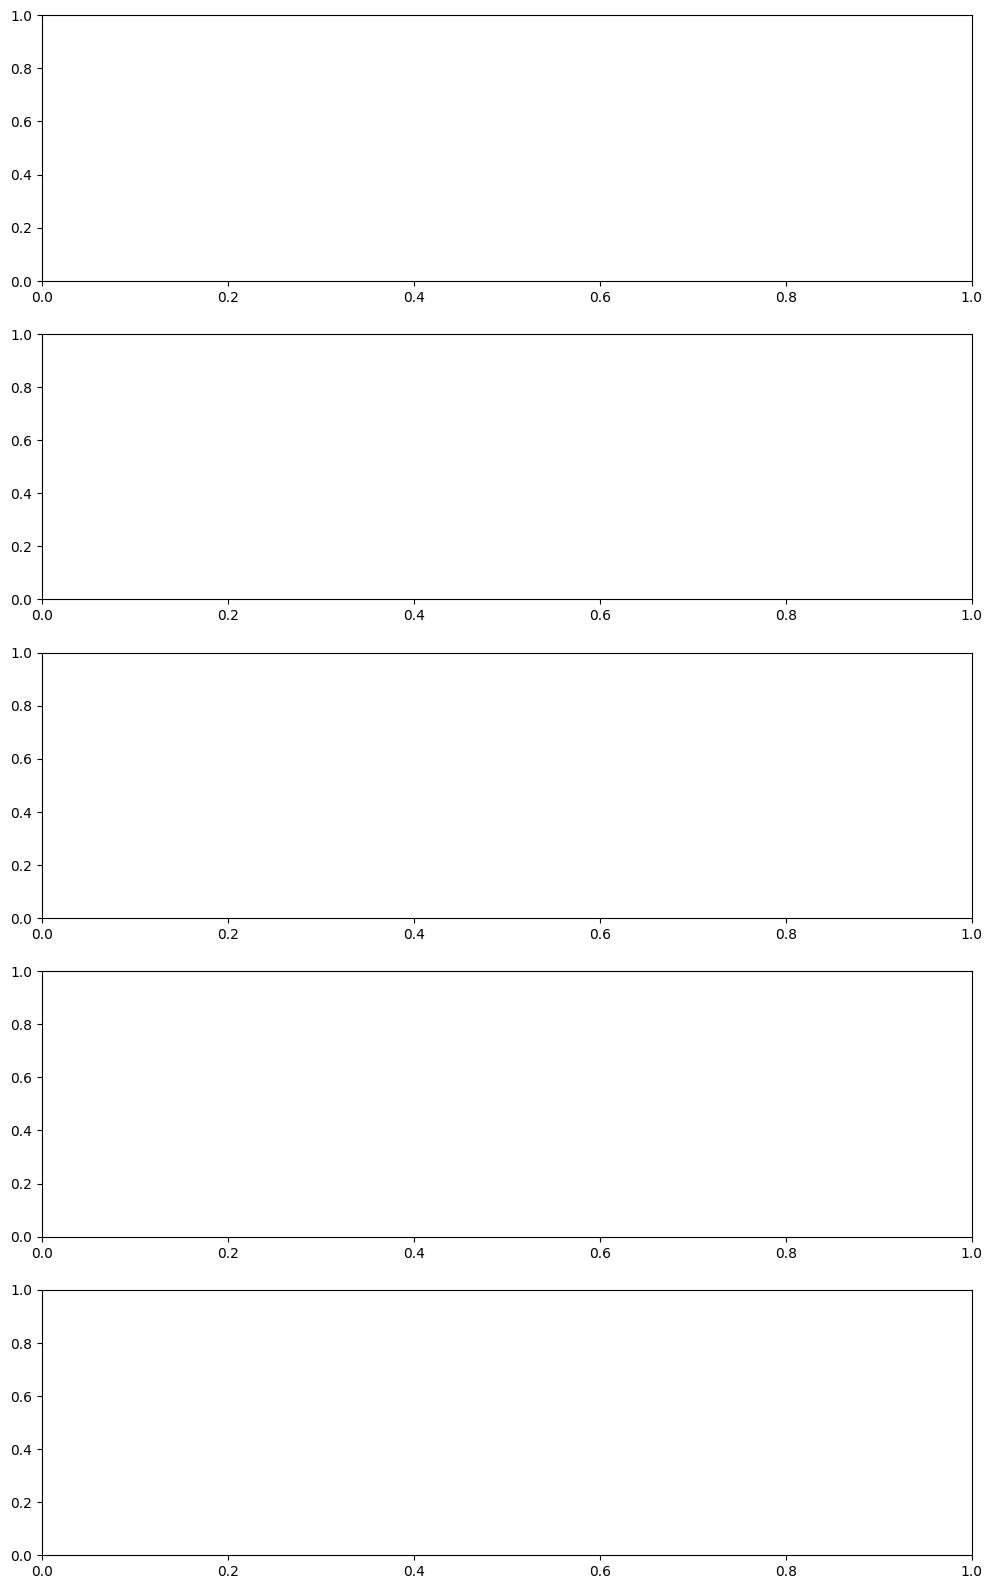

In [23]:
# Cell 23: Run inference on test samples and visualize

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

def visualize_predictions(model, dataset, num_samples=5):
    """
    Generate captions and visualize results
    """
    fig, axes = plt.subplots(num_samples, 1, figsize=(12, 4*num_samples))
    if num_samples == 1:
        axes = [axes]
    
    for i in range(num_samples):
        # Get random sample
        idx = np.random.randint(len(dataset))
        sample = dataset[idx]
        
        # Load image
        image = Image.open(sample['image_path']).convert('RGB')
        
        # Get bbox
        bbox = sample['bbox'].cpu().numpy()
        
        # Generate caption
        with torch.no_grad():
            generated = model.generate_caption(
                image_path=sample['image_path'],
                bbox=bbox,
                max_length=40,
            )
        
        # Visualize
        ax = axes[i]
        ax.imshow(image)
        
        # Draw bounding box
        x1, y1, x2, y2 = bbox
        rect = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=3,
            edgecolor='red',
            facecolor='none'
        )
        ax.add_patch(rect)
        
        # Add text
        ax.set_title(
            f"GT: {sample['caption']}\n"
            f"Generated: {generated}",
            fontsize=10,
            wrap=True
        )
        ax.axis('off')
    
    plt.tight_layout()
    plt.savefig(f"{DATA_CONFIG['output_dir']}/predictions.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"✓ Predictions saved to {DATA_CONFIG['output_dir']}/predictions.png")

# Run visualization on validation set
print("Generating predictions...")
visualize_predictions(complete_model, val_dataset, num_samples=5)

In [ ]:
# Cell 24: Full evaluation with metrics

@torch.no_grad()
def full_evaluation(model, dataset, num_samples=500, output_file='evaluation_results.json'):
    """
    Run comprehensive evaluation and save results
    """
    model.eval()
    
    results = []
    
    print(f"Running full evaluation on {num_samples} samples...")
    
    for i in tqdm(range(min(num_samples, len(dataset)))):
        sample = dataset[i]
        
        try:
            # Generate caption
            generated = model.generate_caption(
                image_path=sample['image_path'],
                bbox=sample['bbox'].cpu().numpy(),
                max_length=40,
            )
            
            result = {
                'image_id': sample['image_id'],
                'region_id': sample['region_id'],
                'bbox': sample['bbox'].tolist(),
                'ground_truth': sample['caption'],
                'generated': generated,
            }
            results.append(result)
            
        except Exception as e:
            print(f"Error at sample {i}: {e}")
            continue
    
    # Compute metrics
    bleu_score = compute_bleu_score(results)
    
    # Save results
    output_path = f"{DATA_CONFIG['output_dir']}/{output_file}"
    with open(output_path, 'w') as f:
        json.dump({
            'num_samples': len(results),
            'bleu_4': float(bleu_score),
            'results': results[:50],  # Save first 50 for inspection
        }, f, indent=2)
    
    print(f"\n{'='*60}")
    print(f"EVALUATION RESULTS")
    print(f"{'='*60}")
    print(f"Samples evaluated: {len(results)}")
    print(f"BLEU-4 Score: {bleu_score:.4f}")
    print(f"Results saved to: {output_path}")
    print(f"{'='*60}")
    
    return results, bleu_score

# Run full evaluation
eval_results, final_bleu = full_evaluation(
    complete_model, 
    val_dataset, 
    num_samples=500
)

In [ ]:
# Cell 25: Training summary and next steps

print("="*60)
print("TRAINING COMPLETE - SUMMARY")
print("="*60)

print("\n📊 Model Architecture:")
print(f"  Visual Encoder: GRiT ViT-B (frozen)")
print(f"  Visual Projector: 768 → 4096 dim, 196 → 32 tokens")
print(f"  LLM Decoder: GritLM-7B (4-bit, with cross-attention)")
print(f"  Trainable Parameters: {sum(p.numel() for p in complete_model.parameters() if p.requires_grad):,}")

print("\n📈 Training Results:")
print(f"  Epochs: {TRAINING_CONFIG['num_epochs']}")
print(f"  Samples: {TRAINING_CONFIG['subset_size'] if TRAINING_CONFIG['use_subset'] else len(train_dataset):,}")
print(f"  Best Validation BLEU-4: {training_history['best_val_bleu']:.4f}")
print(f"  Final Test BLEU-4: {final_bleu:.4f}")

print("\n💾 Saved Artifacts:")
print(f"  Checkpoints: {DATA_CONFIG['checkpoint_dir']}")
print(f"  Outputs: {DATA_CONFIG['output_dir']}")
print(f"  Training curves: {DATA_CONFIG['output_dir']}/training_curves.png")
print(f"  Predictions: {DATA_CONFIG['output_dir']}/predictions.png")

print("\n🚀 Next Steps:")
print("  1. To train on FULL dataset (108K images):")
print("     Set TRAINING_CONFIG['use_subset'] = False")
print("     This will take ~20-30 hours on Kaggle")
print()
print("  2. To improve results further:")
print("     - Increase num_epochs (3 → 5)")
print("     - Add diffusion features (as per original plan)")
print("     - Fine-tune learning rate")
print()
print("  3. For inference on new images:")
print("     Use complete_model.generate_caption(image_path, bbox)")
print()
print("  4. For deployment:")
print("     Export model with torch.save() and use in production")

print("\n✓ All done! Model is ready for dense captioning.")
print("="*60)

In [ ]:
# Cell 26: Simple inference function for new images

def quick_inference(image_path_or_url, bbox_xywh=None, show_result=True):
    """
    Quick inference on a single image.
    
    Args:
        image_path_or_url: Path to local image or URL
        bbox_xywh: [x, y, width, height] or None to use full image
        show_result: Whether to display the image with caption
    
    Returns:
        generated_caption: String caption
    """
    # Load image
    if image_path_or_url.startswith('http'):
        import requests
        from io import BytesIO
        response = requests.get(image_path_or_url)
        image = Image.open(BytesIO(response.content)).convert('RGB')
        # Save temporarily
        temp_path = os.path.join(os.environ.get('TEMP', '.'), 'temp_image.jpg')
        image.save(temp_path)
        image_path = temp_path
    else:
        image = Image.open(image_path_or_url).convert('RGB')
        image_path = image_path_or_url
    
    # Handle bbox
    if bbox_xywh is None:
        # Use full image
        w, h = image.size
        bbox = [0, 0, w, h]
    else:
        x, y, w, h = bbox_xywh
        bbox = [x, y, x+w, y+h]
    
    # Generate caption
    with torch.no_grad():
        caption = complete_model.generate_caption(
            image_path=image_path,
            bbox=bbox,
            max_length=40,
        )
    
    # Visualize
    if show_result:
        plt.figure(figsize=(10, 6))
        plt.imshow(image)
        
        # Draw box
        x1, y1, x2, y2 = bbox
        rect = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=3,
            edgecolor='red',
            facecolor='none'
        )
        plt.gca().add_patch(rect)
        
        plt.title(f"Generated: {caption}", fontsize=14, wrap=True)
        plt.axis('off')
        plt.tight_layout()
        plt.show()
    
    return caption

print("✓ Quick inference function ready!")
print("\nUsage:")
print("  caption = quick_inference('/path/to/image.jpg', bbox_xywh=[100, 100, 200, 150])")
print("  # or for full image:")
print("  caption = quick_inference('/path/to/image.jpg')")